# Setup and download data

This tutorials shows how to set up an multiple slide Visium dataset used in [Withnell & Secrier, 2024](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-024-03428-y). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://zenodo.org/records/13907274)

In [7]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns

from pathlib import Path

In [8]:
from pathlib import Path

# set INTERSCALE_DIR to the current working directory
INTERSCALE_DIR = Path.cwd()
print(INTERSCALE_DIR)

/workspace


<mark>TODO: Change data path</mark>

In [9]:
VISIUM_BREAST = '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/visium_tme.h5ad'  

## Load data

In [10]:
adata_breast = sc.read_h5ad(VISIUM_BREAST)
adata_breast

AnnData object with n_obs × n_vars = 30562 × 14664
    obs: 'array_row', 'array_col', 'batch', 'angio_hallmarks', 'cell_prolif', 'tumour_cells', 'nk_cells', 'macro_lam2', 'EPI', 'EMT', 'hypoxia_hallmarks_hot', 'hypoxia_hallmarks_cold', 'angio_hallmarks_hot', 'angio_hallmarks_cold', 'nk_cells_hot', 'nk_cells_cold', 'EPI_hot', 'EPI_cold', 'EPI_hot_number', 'EPI_cold_number', 'EMT_hot', 'EMT_cold', 'EMT_hot_number', 'EMT_cold_number', 'angio_hallmarks_hot_number', 'angio_hallmarks_cold_number', 'nk_cells_hot_number', 'nk_cells_cold_number', 'response_to_check_point_score'
    uns: 'spatial'
    obsm: 'MT', 'spatial'

## 1. Normalization

The data needs to be normalized for InterScale. Check if the data is already normalized: 

In [6]:
print(f'Min count: {adata_breast.X.min()}, Max count: {adata_breast.X.max()}')

Min count: 0.0, Max count: 7513.0


The data is not yet normalized, so normalize and transform with log1p.

In [7]:
scales_counts = sc.pp.normalize_total(adata_breast, target_sum=None, inplace=False)
adata_breast.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [8]:
print(f'Min count: {adata_breast.layers["log1p_norm"].min()}, Max count: {adata_breast.layers["log1p_norm"].max()}')

Min count: 0.0, Max count: 8.146011352539062


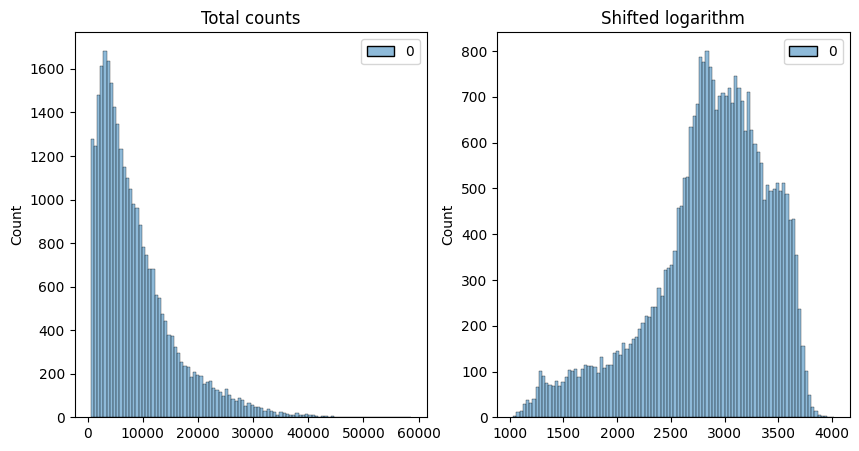

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_breast.X.sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata_breast.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For Visium it is important to set `coord_type='grid'` and indicate the IDs per slide (e.i. `batch_id`)

In [10]:
np.unique(adata_breast.obs['batch'])

array(['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9'],
      dtype=object)

In [11]:
sq.gr.spatial_neighbors(
    adata_breast,
    coord_type = "grid",
    library_key = "batch"
)

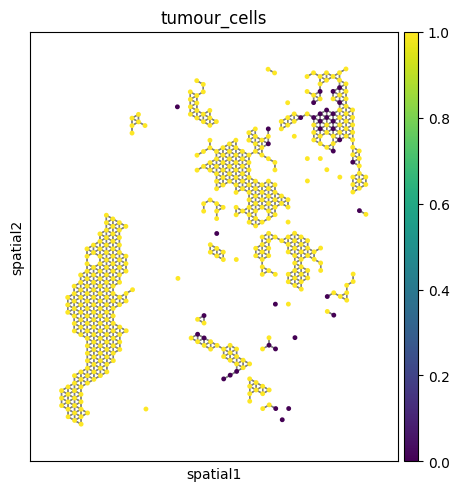

In [12]:
sq.pl.spatial_scatter(
    adata_breast,
    library_key='batch',
    library_id = '1',
    connectivity_key="spatial_connectivities",
    img=False,
    color=["tumour_cells"]
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [13]:
tissue_cell_number = adata_breast.obs.groupby('batch').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 496, Max: 4875, Avg: 2546.8333333333335


/tmp/ipykernel_2336676/1736762428.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_breast.obs.groupby('batch').size()


<AxesSubplot: xlabel='batch'>

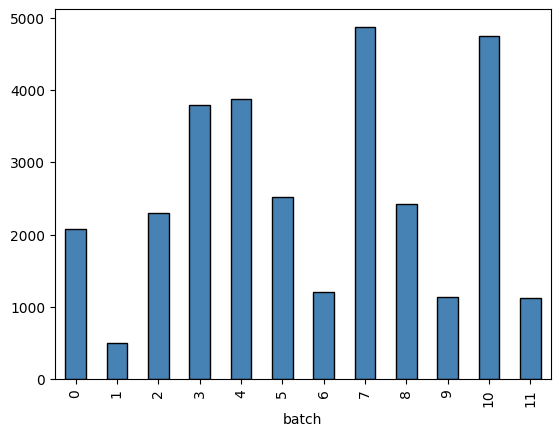

In [14]:
tissue_cell_number.plot(kind='bar', color='steelblue', edgecolor='black')

We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

In [16]:
batches_over_4k = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_over_4k)

batch
7     4875
10    4744
dtype: int64


In [30]:
del adata_breast.obs['sliding_window_assignment']

In [43]:
sq.tl.sliding_window(
    adata=adata_breast,
    library_key="batch",  # to stratify by sample
    window_size=10000,
    overlap=0,
    copy=False,  # we modify in place
)

In [44]:
window_size = adata_breast.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 57, Max: 2418, Avg: 985.8709677419355


/tmp/ipykernel_2336676/2739523918.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_size = adata_breast.obs.groupby('sliding_window_assignment').size()


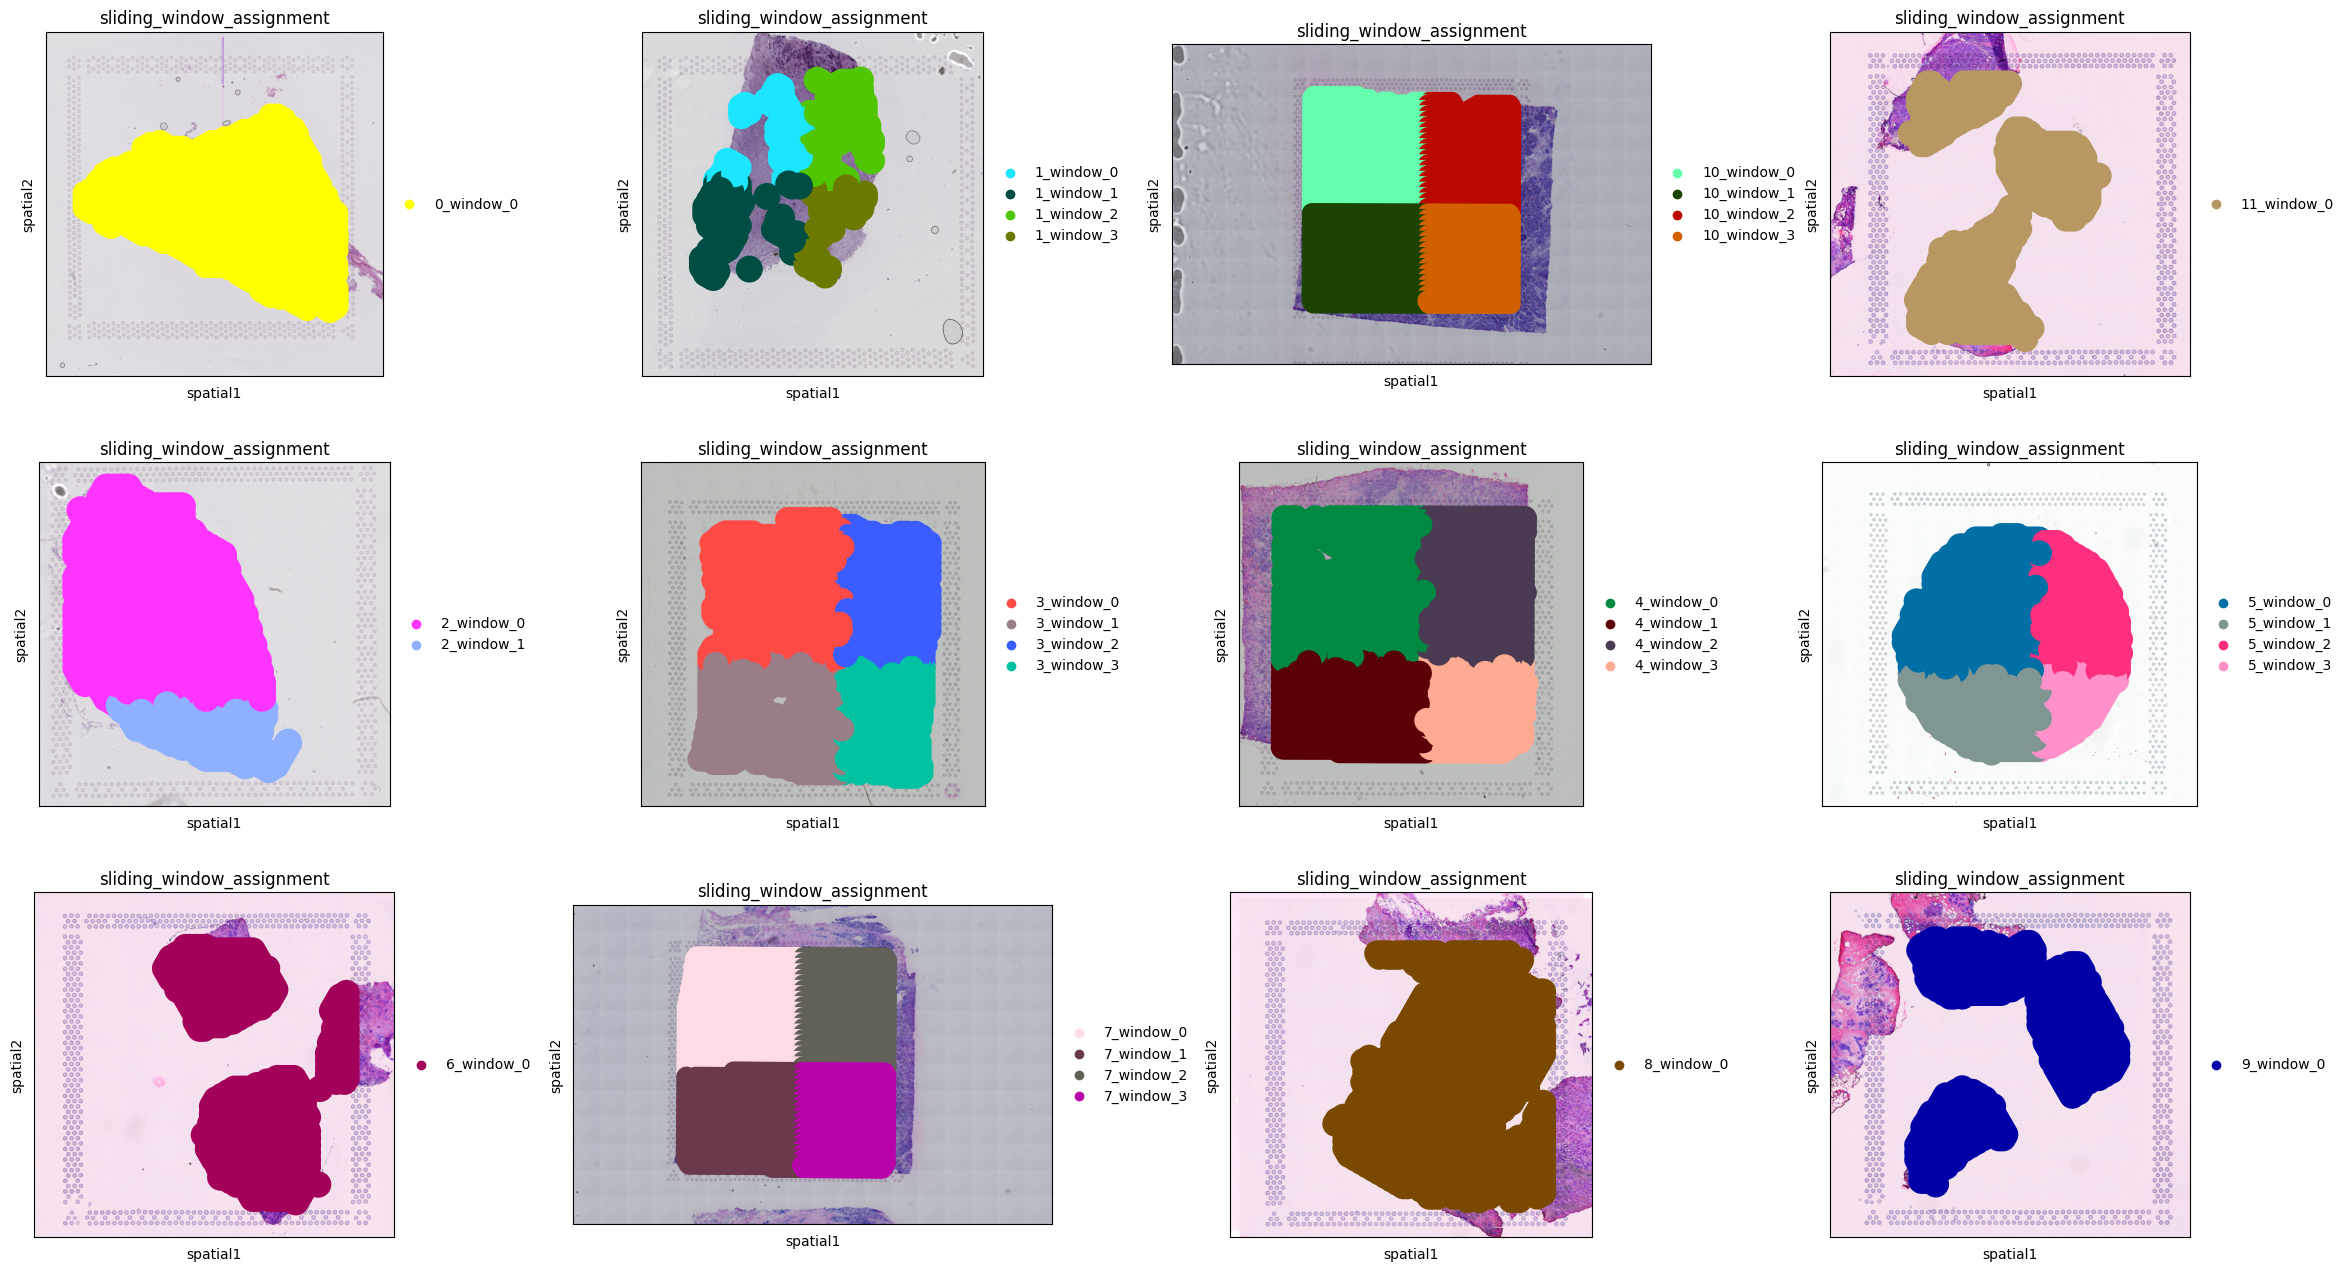

In [45]:
sq.pl.spatial_scatter(
    adata_breast,
    spatial_key = 'spatial',
    library_key='batch', 
    color="sliding_window_assignment", #cell_type_coarse",
    size = 10,
)

With the sliding windows the maximum number of cells per sliding window is `2418`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2418`. The default is `2000`.

## 4. Split data into train and val set

Training the model requires a `split` assignment for each donor/patient/sliding window that you wanna train on. 

In [21]:
from sklearn.model_selection import train_test_split

In [31]:
df = pd.DataFrame({
    'sliding_window_assignment': adata_breast.obs['sliding_window_assignment'],
    'batch': adata_breast.obs['batch']
})


X_train, X_test, y_train, y_test = train_test_split(
    df['sliding_window_assignment'],  # Features (sliding window assignments)
    df['batch'],                       # Target (batch) - used for stratification
    test_size=0.2,                     # Adjust this ratio as needed (80/20 split by default)
    stratify=df['batch'],              # Stratify based on batch column
    random_state=42                    # For reproducibility
)

# Create a new column in the DataFrame to indicate train/test assignment
df['split'] = 'train'  # Initialize all as train
df.loc[X_test.index, 'split'] = 'val'  # Mark test indices

# Alternatively, if you want to add this back to your adata object:
adata_breast.obs['split'] = df['split']

In [32]:
adata_breast.obs['split']

AAACAGTGTTCCTGGG-1_-0     train
AAACCGGGTAGGTACC-1_-0       val
AAACCGTTCGTCCAGG-1_-0     train
AAACCTAAGCAGCCGG-1_-0     train
AAACGAAGAACATACC-1_-0     train
                          ...  
ATGGTATTGGGAACCG-1_-11      val
CTCTACATCCTGCGTG-1_-11    train
TGGGTGTTAAGTAGAA-1_-11    train
CGATCGAGAAGCACCA-1_-11    train
CTGCTCTGACGGCAAA-1_-11      val
Name: split, Length: 30562, dtype: object

## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [33]:
adata_breast.write('/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/visium_tme_pp.h5ad'  )

## Prepare config file

Duplicate the minum requirement config file from `/GT-long-range-niches/src/config_files/InterScale_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2418
  save: /path/to/save/model/
dataset:
  h5ad_data: visium_tme_pp.h5ad
  name: Visium_breast_cancer_TME
  sample_key: ['batch']
  spatial_neigbors_kwargs:
    coord_type: grid
    library_key: batch
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).